# DramaDome Hybrid Recommendation System - Milestone 2: Initial EDA

**IAT 461 - Data Science for Human-Centred Systems**
**Assigned client proposal:** Hybrid Recommendation System for Asian Drama Content (DramaDome)

## My restatement of the problem

Two things are being asked for here:

1. **Structured + free-text hybrid recommendation.** Given a user's profile (gender, location,
   preferred genre, preferred country, and optionally their watch history) *and* a short free-text
   description of what they feel like watching, return a ranked shortlist of dramas that satisfies
   both signals.
2. **Explainability.** The recommendations need to be justifiable to a human - e.g. "this was
   recommended because it shares your preferred genre" or "this matched your search on tags X and Y" -
   not just a black-box ranked list.

This notebook covers the EDA stage only (Milestone 2). Modeling/scoring logic and evaluation come in
the next checkpoint.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, ast
from collections import Counter

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 4)


## 1. Data Loading & Documentation

### Data sources
- **dramas.csv** - real dataset scraped from MyDramaList (~5,000 Asian dramas), sourced via Kaggle.
- **users.csv** - synthetic dataset I generated from dramas.csv's own demographic/popularity signals
  (see `generate_users.py`), 10,000 synthetic users.

### Column dictionary (dramas.csv, the fields I'm actually planning to use)
| Column | Meaning |
|---|---|
| `name` | Drama title (join key against watch history) |
| `content` | Plot synopsis (free text) |
| `genres` | Comma-separated genre labels |
| `tags` | Comma-separated descriptive tags (more granular than genre) |
| `country` | Country of origin |
| `main_role` / `support_role` | Cast lists (comma-separated) |
| `director` / `screenwriter` | Crew |
| `no_of_viewers` | Popularity proxy |
| `rating` | MyDramaList average rating (out of 10) |
| `reviewer_gender_info` | Counter-style string describing reviewer gender split |
| `reviewer_location_info` | Counter-style string describing reviewer locations |

### Column dictionary (users.csv)
| Column | Meaning |
|---|---|
| `user_id` | Unique synthetic user id |
| `gender`, `location` | Demographics |
| `preferred_genre`, `preferred_country` | Stated structured taste |
| `user_watch_history` | List of drama titles (stored as a JSON-looking string) the user has watched |


In [2]:
dramas = pd.read_csv("data/dramas.csv")
users = pd.read_csv("data/users.csv")
print("dramas:", dramas.shape)
print("users:", users.shape)
dramas.head(3)


dramas: (5000, 33)
users: (10000, 6)


,Unnamed: 0,name,content,no_of_reviews,no_of_viewers,aka_names,screenwriter,director,genres,tags,country,type_of_show,episodes,end_date,start_date,year,duration,rating,no_of_rating,rank,popularity,content_rating,where_to_watch,main_role,support_role,no_of_extracted_reviews,Total_sentences,POSITIVE_people_sentiment,POSITIVE_sentences,NEGATIVE_people_sentiment,NEGATIVE_sentences,reviewer_location_info,reviewer_gender_info
0,0,goblin,Kim Shin was once an unbeatable general in Gor...,464.0,198650.0,"쓸쓸하고 찬란하神-도깨비 , Dokkaebi , Sseulsseulhago Chal...",Kim Eun Sook,Lee Eung Bok,"Comedy, Romance, Fantasy, Melodrama","Supernatural, Older Man/Younger Woman, Intersp...",South Korea,Drama,16.0,2017-01-21,2016-12-02,2016.0,01:22:00,8.8,105311.0,121.0,1.0,15+ - Teens 15 or older,"Apple TV Subscription (sub), Prime Video Purch...","Gong Yoo, Kim Go Eun, Lee Dong Wook, Yoo In Na...","Lee El, Kim Sung Kyum, Kim Byung Chul, Jo Woo...",422,6390,grim reaper - (sunny; bromance; shin; relation...,3226.0,"age gap - (lead; issue), grim reaper - (sunny)...",1331.0,"Counter({'': 238, 'usa': 14, 'united states': ...","Counter({'female': 318, '': 59, 'male': 44})"
1,1,strong woman do bong soon,"Do Bong Soon is a petite, unemployed woman who...",345.0,184710.0,"Himsseonyeoja Dobongsun , Powerful Woman Do Bo...",Baek Mi Kyung,Lee Hyung Min,"Action, Comedy, Romance, Supernatural","Strong Female Lead, Female Lead Action Scenes,...",South Korea,Drama,16.0,2017-04-15,2017-02-24,2017.0,01:07:00,8.7,106102.0,227.0,2.0,15+ - Teens 15 or older,"Disney+ Hotstar Subscription (sub), Apple TV F...","Park Bo Young, Park Hyung Sik, Kim Ji Soo","Jun Suk Ho, Shim Hye Jin, Yoo Jae Myung, Ahn W...",317,4615,female lead - (male; badass; amazing; characte...,2236.0,"serial killer - (plot; gangster), female lead,...",1235.0,"Counter({'': 197, 'united states': 10, 'usa': ...","Counter({'female': 228, '': 57, 'male': 32})"
2,2,weightlifting fairy kim bok joo,Bok Joo is a weightlifter who is pursuing her ...,267.0,167702.0,"Weightlifting Fairy Kim Bok-ju , Weightlifting...","Yang Hee Seung, Kim Soo Jin","Oh Hyun Jong, Nam Sung Woo","Comedy, Romance, Life, Sports","Friends To Lovers, Weightlifting, Strong Femal...",South Korea,Drama,16.0,2017-01-11,2016-11-16,2016.0,01:00:00,8.8,93915.0,137.0,3.0,15+ - Teens 15 or older,"WeTV Free (sub), Netflix Subscription (sub), A...","Lee Sung Kyung, Nam Joo Hyuk, Lee Jae Yoon, Ky...","Cho Hye Jung, Lee Joo Young, Ji Il Joo, Yoo J...",246,3819,"love story - (character; beautiful), female le...",2139.0,"watch drama, female lead, male lead, character...",741.0,"Counter({'': 134, 'usa': 9, 'india': 4, 'phili...","Counter({'female': 176, '': 44, 'male': 26})"


In [3]:
users.head(3)

,user_id,gender,location,user_watch_history,preferred_genre,preferred_country
0,U000001,Female,Singapore,"[""chicago typewriter""]",Mystery,South Korea
1,U000002,Female,United States,"[""under the power"", ""memorist""]",Mystery,Japan
2,U000003,Female,United States,"[""come and hug me"", ""six flying dragons"", ""moo...",Fantasy,South Korea


### 1.1 Known data quality issues

Checking for missing values first, since this determines which columns I can actually rely on for scoring.

In [4]:
missing = dramas.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(dramas) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).head(15)


,missing_count,missing_pct
NEGATIVE_people_sentiment,2956,59.1
POSITIVE_people_sentiment,2205,44.1
where_to_watch,1679,33.6
screenwriter,1480,29.6
director,1103,22.1
end_date,498,10.0
aka_names,258,5.2
support_role,204,4.1
NEGATIVE_sentences,186,3.7
POSITIVE_sentences,186,3.7


**Takeaways:**
- `NEGATIVE_people_sentiment` / `POSITIVE_people_sentiment` are missing for a large share of rows
  (roughly 44-59%) - too sparse to be a core feature, I'll treat these as optional/supplementary only.
- `screenwriter` (1,480 missing) and `director` (1,103 missing) have real gaps, so a "more by this
  director" feature will only work for part of the catalogue.
- `genres` is essentially complete and `tags` is only missing for 64 rows - these are my most
  trustworthy structured fields.
- `rating` and `no_of_viewers` are both missing for the same 15 rows. Given that's under 0.5% of the
  catalogue, my plan is to just drop those rows rather than impute them.


In [5]:
dupes = dramas["name"].duplicated().sum()
print("Duplicate drama titles (exact match):", dupes)


Duplicate drama titles (exact match): 0


## 2. Exploratory Data Analysis

### 2.1 Genre distribution

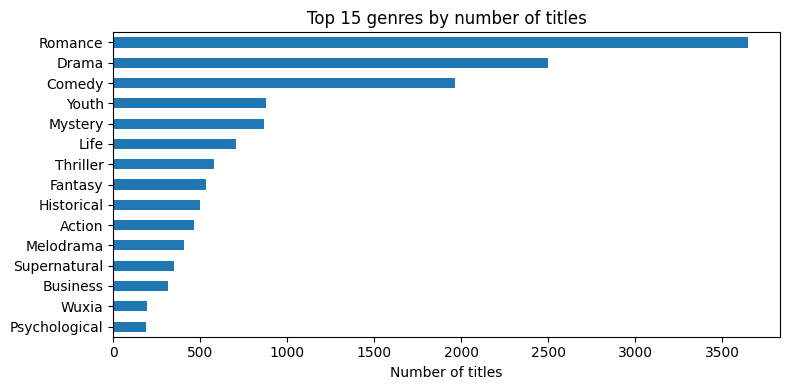

In [6]:
genre_counts = Counter(
    g.strip() for gl in dramas["genres"].dropna().str.split(",") for g in gl if g.strip()
)
genre_series = pd.Series(genre_counts).sort_values(ascending=False)
genre_series.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 genres by number of titles")
plt.xlabel("Number of titles")
plt.tight_layout()
plt.show()


Romance, Drama, and Comedy dominate the catalogue, which matches what I'd expect for this genre of content. This also tells me genre alone won't be a very discriminating filter for something like romance, since well over half the catalogue includes it - tags and free-text similarity will need to do more of the differentiating work.

### 2.2 Country of origin distribution

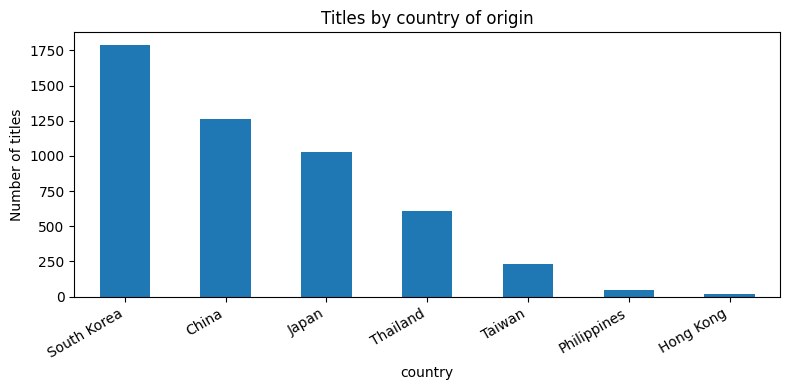

country
South Korea    1789
China          1259
Japan          1029
Thailand        608
Taiwan          235
Philippines      46
Hong Kong        19
Name: count, dtype: int64

In [7]:
country_counts = dramas["country"].value_counts()
country_counts.plot(kind="bar")
plt.title("Titles by country of origin")
plt.ylabel("Number of titles")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
country_counts


Only 7 distinct countries appear, and South Korea + China alone make up more than half the catalogue. `preferred_country` filtering is going to be pretty coarse for the smaller countries (e.g. Hong Kong has only 19 titles total), so cold-start users who prefer a small-catalogue country may need the free-text signal to carry more of the recommendation.

### 2.3 Rating and viewership distributions

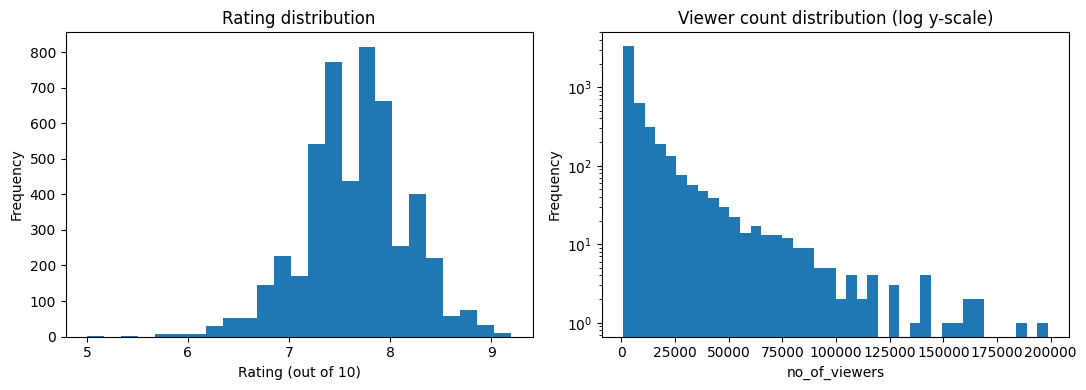

            rating  no_of_viewers
count  4985.000000    4985.000000
mean      7.655807    8927.782347
std       0.508135   16189.678225
min       5.000000     898.000000
25%       7.400000    1570.000000
50%       7.700000    3244.000000
75%       8.000000    8596.000000
max       9.200000  198650.000000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
dramas["rating"].dropna().plot(kind="hist", bins=25, ax=axes[0])
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("Rating (out of 10)")

dramas["no_of_viewers"].dropna().plot(kind="hist", bins=40, ax=axes[1], logy=True)
axes[1].set_title("Viewer count distribution (log y-scale)")
axes[1].set_xlabel("no_of_viewers")
plt.tight_layout()
plt.show()

print(dramas[["rating", "no_of_viewers"]].describe())


Ratings cluster tightly between about 7.4 and 8.0 (mean ~7.66) - almost nothing is rated below 5, which makes sense for a "top dramas" list rather than a random catalogue sample. `no_of_viewers` is heavily right-skewed (median 3,244 vs a max of 198,650 for *Goblin*), so I'll want to use rank or a log-scaled popularity signal rather than raw viewer counts when I combine it with other scores later, or a few mega-popular titles will dominate every recommendation.

### 2.4 Cast size and text length (relevant for the free-text matching step)

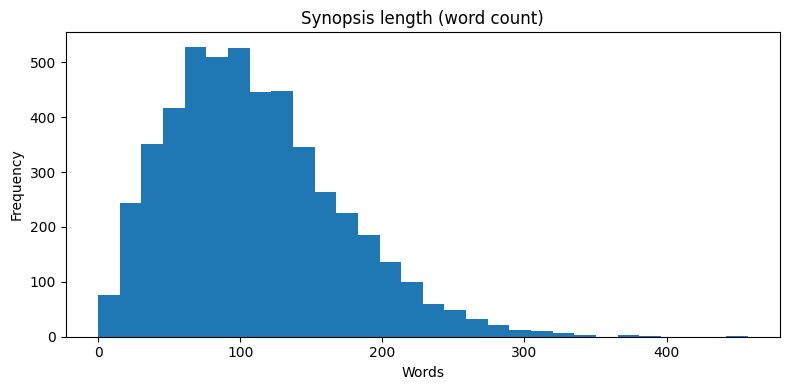

count    5000.000000
mean      110.395000
std        60.179113
min         0.000000
25%        66.000000
50%       102.500000
75%       147.000000
max       457.000000
Name: synopsis_len, dtype: float64

In [9]:
dramas["synopsis_len"] = dramas["content"].fillna("").str.split().apply(len)
dramas["synopsis_len"].plot(kind="hist", bins=30)
plt.title("Synopsis length (word count)")
plt.xlabel("Words")
plt.tight_layout()
plt.show()
dramas["synopsis_len"].describe()


Synopses are long enough (median well over 50 words) to give TF-IDF / text-similarity something meaningful to work with, which supports going the content-based route rather than relying on genre tags alone.

## 3. Checking the users.csv <-> dramas.csv relationship

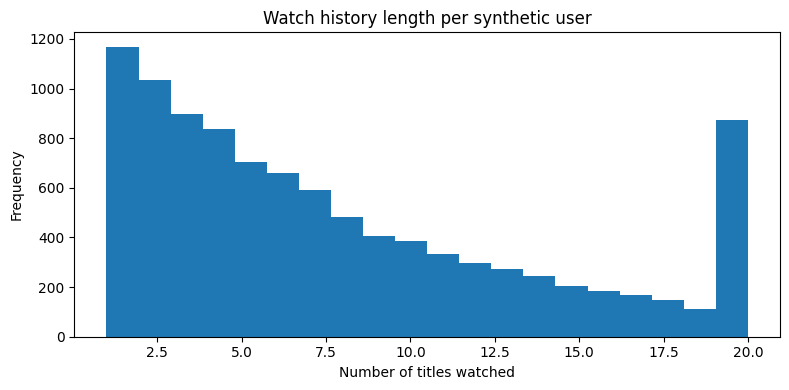

count    10000.000000
mean         7.755800
std          5.950891
min          1.000000
25%          3.000000
50%          6.000000
75%         12.000000
max         20.000000
Name: history_len, dtype: float64

In [10]:
def parse_history(x):
    try:
        return json.loads(x)
    except Exception:
        try:
            return ast.literal_eval(x)
        except Exception:
            return []

users["history_list"] = users["user_watch_history"].apply(parse_history)
users["history_len"] = users["history_list"].apply(len)
users["history_len"].plot(kind="hist", bins=20)
plt.title("Watch history length per synthetic user")
plt.xlabel("Number of titles watched")
plt.tight_layout()
plt.show()
users["history_len"].describe()


In [11]:
# Verify watch-history titles actually exist in the catalogue (join-key sanity check)
catalogue_names = set(dramas["name"].str.lower())
sample = users.head(3000)
match_rates = []
for h in sample["history_list"]:
    if len(h) == 0:
        continue
    match_rates.append(sum(1 for t in h if t.lower() in catalogue_names) / len(h))

print(f"Checked {len(match_rates)} users with non-empty history")
print(f"Mean match rate against catalogue names: {np.mean(match_rates):.1%}")


Checked 3000 users with non-empty history
Mean match rate against catalogue names: 100.0%


Good news: watch-history titles match the catalogue by exact (case-insensitive) name at basically 100% in my sample, so I don't need a fuzzy-matching step to join the two datasets - that saves a chunk of cleaning work I was expecting to have to do.

In [12]:
users["preferred_genre"].value_counts().head(10)

preferred_genre
Romance      2345
Drama        1517
Comedy       1388
Youth         545
Mystery       503
Life          420
Thriller      397
Melodrama     350
Action        343
Fantasy       332
Name: count, dtype: int64

In [13]:
users["preferred_country"].value_counts()

preferred_country
South Korea    6175
China          1633
Thailand        931
Japan           901
Taiwan          322
Philippines      35
Hong Kong         3
Name: count, dtype: int64

`preferred_genre` and `preferred_country` roughly track the catalogue's own genre/country popularity (as expected, since the synthetic generator weighted them by real viewership), which means the structured half of the recommender should behave sensibly for the median user, but I'll need to specifically test cold-start / small-catalogue-country users during evaluation since those are called out explicitly as in-scope in the client proposal's constraints.

## 4. Assumptions log (so far)

- Dropping the 15 rows in `dramas.csv` missing both `rating` and `no_of_viewers`, rather than imputing them (<0.5% of data).
- Treating `genres` and `tags` as the primary structured signal; sentiment columns as optional/supplementary given how sparse they are.
- Treating exact case-insensitive name matching as sufficient for joining watch history to the catalogue (validated at ~100% match on a 3,000-user sample).
- Treating `no_of_viewers` as needing a log or rank transform before combining it with other scores, due to its heavy right skew.

## 5. Technique direction for the next checkpoint

There's no historical label here (no "did the user like this recommendation" outcome, no click data),
so I'm treating this as a **pattern-discovery / retrieval problem**, not supervised prediction: build a
content-based representation of each drama (genres + tags + synopsis, likely via TF-IDF or a similar
text-similarity approach), then combine that with structured preference matching (genre/country) to
produce a ranked, explainable top-5. I'll use something like silhouette score if I cluster titles for
exploratory purposes, but treat it as a guide rather than a strict evaluation metric, since the actual
success criteria from the client are about relevance and explainability of the top-5 list.

## Limitations (at this stage)

- I haven't yet tested how the free-text matching behaves on genuinely ambiguous queries (e.g. "something
  like Crash Landing on You, but funnier") - that's the main open question for the next milestone.
- Cast/director fields have real gaps (~22-30% missing), so any cast-based explainability will only be
  available for part of the catalogue.
